<a href="https://colab.research.google.com/github/uditmodi2322-bot/Gold-predictions/blob/main/migrane_stage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd

# Download the latest version
path = kagglehub.dataset_download("harideepak/migrane-stage-data")
print("Path to dataset files:", path)

# List files and load the CSV
files = os.listdir(path)
print("Files found:", files)
file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

print("\nFirst 5 rows of raw data:")
df.head()

100%|██████████| 10.6k/10.6k [00:00<00:00, 9.65MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harideepak/migrane-stage-data/versions/1
Files found: ['migraine_stage_data.csv']

First 5 rows of raw data:


,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Vertigo,Tinnitus,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF,Migraine_Stage
0,56,32,1,2,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Stage 1 - Prodrome
1,69,9,3,2,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Stage 1 - Prodrome
2,46,19,13,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Stage 1 - Prodrome
3,32,48,12,4,2,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Stage 1 - Prodrome
4,60,3,14,3,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Stage 1 - Prodrome


In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Handle missing values
df = df.fillna(df.mode().iloc[0])

# 2. Setup Target Encoding
target_col = 'Migraine_Stage'
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))

# --- CRITICAL UPDATE: MANUALLY ALIGN FEATURE ORDER ---
# This ensures Column 0 is Age, Column 3 is Intensity, etc., matching your Django code.
form_features = [
    'Age', 'Duration', 'Frequency', 'Intensity',
    'Nausea', 'Photophobia', 'Phonophobia', 'Visual', 'Vertigo', 'Sensory', 'Dysphasia'
]

# Get all other columns in your CSV that aren't in the form or target
other_cols = [c for c in df.columns if c not in form_features and c != target_col]

# Join them so the 11 form fields come first
final_feature_order = form_features + other_cols

# 3. Define Features (X) using the new order
X = df[final_feature_order]
y = df[target_col]

# 4. FEATURE SCALING (Fixes the "Stage 0" bias)
# This normalizes Intensity (1-10) to a 0-1 range so the model pays attention to it.
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to keep the names (this stops the UserWarnings later)
X_final = pd.DataFrame(X_scaled, columns=final_feature_order)

# 5. Split and Save
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Save the 3 keys for the Django app
joblib.dump(final_feature_order, 'feature_names.pkl')
joblib.dump(le_target, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl') # IMPORTANT: Save this to use in views.py

print(f"✅ Preprocessing Complete.")
print(f"Total Features: {len(final_feature_order)}")
print(f"Primary Features (Must match Django order): {form_features}")

✅ Preprocessing Complete.
Total Features: 23
Primary Features (Must match Django order): ['Age', 'Duration', 'Frequency', 'Intensity', 'Nausea', 'Photophobia', 'Phonophobia', 'Visual', 'Vertigo', 'Sensory', 'Dysphasia']


In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. PREPROCESSING
# Fill missing values
df = df.fillna(df.mode().iloc[0])

# Initialize the encoder for the TARGET
le_target = LabelEncoder()
target_col = 'Migraine_Stage'
df[target_col] = le_target.fit_transform(df[target_col].astype(str))

# --- IMPORTANT: FIX COLUMN ORDER ---
# We force the columns to be in the exact order your Django 'data' list uses
# This ensures Intensity is actually read as Intensity!
expected_order = [
    'Age', 'Duration', 'Frequency', 'Intensity',
    'Nausea', 'Photophobia', 'Phonophobia', 'Visual', 'Vertigo', 'Sensory', 'Dysphasia'
]

# Get any remaining columns that are in your CSV but not in your web form
other_cols = [c for c in df.columns if c not in expected_order and c != target_col]
final_column_order = expected_order + other_cols

X = df[final_column_order]
y = df[target_col]

# 2. SCALING (This makes Intensity more powerful)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. TRAINING
model = RandomForestClassifier(
    n_estimators=200,      # Increased trees for better sensitivity
    max_depth=10,          # Prevents the model from getting "stuck" on one feature
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model Training Complete with Feature Alignment.")

# 4. VERIFICATION
importances = pd.Series(model.feature_importances_, index=final_column_order)
print("\n--- Feature Importance (Check if Intensity is high here) ---")
print(importances.sort_values(ascending=False).head(10))

# 5. SAVE EVERYTHING
joblib.dump(model, 'migraine_model.pkl')
joblib.dump(le_target, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl') # SAVE THE SCALER
joblib.dump(final_column_order, 'feature_names.pkl')

print("\n✅ Files saved. Download migraine_model.pkl, label_encoder.pkl, and scaler.pkl!")

✅ Model Training Complete with Feature Alignment.

--- Feature Importance (Check if Intensity is high here) ---
Intensity      0.247102
Vertigo        0.097714
Dysphasia      0.089188
Visual         0.087797
Conscience     0.080193
Ataxia         0.077026
Sensory        0.070784
Paresthesia    0.052339
Photophobia    0.045064
Nausea         0.042919
dtype: float64

✅ Files saved. Download migraine_model.pkl, label_encoder.pkl, and scaler.pkl!


FINAL MODEL ACCURACY: 96.34%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        64
           1       1.00      0.95      0.98        63
           2       1.00      1.00      1.00        76
           3       1.00      0.86      0.93        43

    accuracy                           0.96       246
   macro avg       0.97      0.95      0.96       246
weighted avg       0.97      0.96      0.96       246



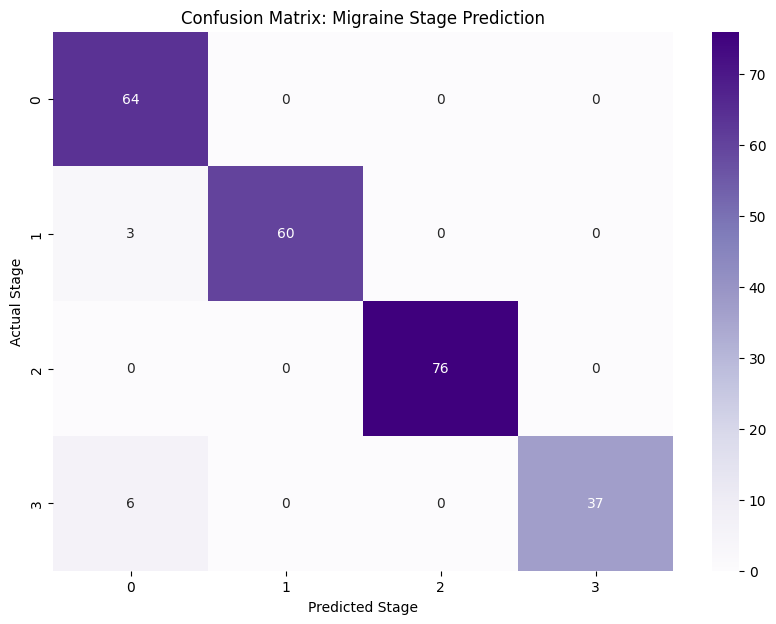

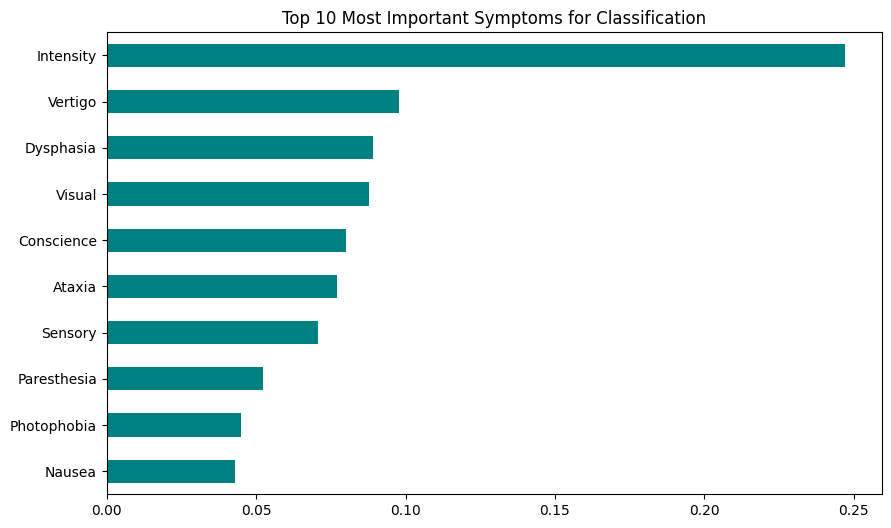

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Calculate Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"FINAL MODEL ACCURACY: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Plot Confusion Matrix
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Migraine Stage Prediction')
plt.xlabel('Predicted Stage')
plt.ylabel('Actual Stage')
plt.show()

# 3. Plot Feature Importance (Which symptoms matter most?)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Symptoms for Classification')
plt.show()

In [ ]:
2import numpy as np
import pandas as pd

# 1. Concise Guide with simplified definitions
feature_guides = {
    "Age": "Years (1-100)",
    "Duration": "Hours of pain (1-72)",
    "Frequency": "Attacks per month (1-30)",
    "Intensity": "Pain scale (1: Low, 10: High)",
    "Nausea": "Stomach upset (0: No, 1: Yes)",
    "Photophobia": "Light sensitivity (0: No, 1: Yes)",
    "Phonophobia": "Sound sensitivity (0: No, 1: Yes)",
    "Visual": "Aura/Zigzag lines (0: No, 1: Yes)",
    "Vertigo": "Dizziness/Spinning (0: No, 1: Yes)",
    "Sensory": "Numbness/Tingling (0: No, 1: Yes)",
    "Dysphasia": "Speech difficulty (0: No, 1: Yes)"
}

print("--- 🧠 Migraine Clinical Diagnosis Tool ---")
print("Provide values for the symptoms below to see the prediction.\n")

user_inputs = {}
# Only iterate through our core guided features to keep it simple
for col in X.columns:
    if col in feature_guides:
        while True:
            val = input(f"➤ {col} [{feature_guides[col]}]: ").strip()
            if val == "":
                print(f"   [!] Required.")
                continue
            try:
                user_inputs[col] = float(val)
                break
            except ValueError:
                print(f"   [!] Enter a number.")
    else:
        # Auto-fill rare neurological symptoms with 0 to keep input short
        user_inputs[col] = 0

# 2. Process for Prediction
final_row = [user_inputs.get(col, 0) for col in X.columns]
final_df = pd.DataFrame([final_row], columns=X.columns)

# 3. Get Prediction and Probabilities
prediction = model.predict(final_df)
probs = model.predict_proba(final_df)
max_prob = np.max(probs)
predicted_class = prediction[0]

# 4. Result logic: If confidence is low, warn the user
print("\n" + "="*50)
print(f"{'DIAGNOSIS REPORT':^50}")
print("="*50)

try:
    stage_name = le.inverse_transform([predicted_class])[0]
except:
    stage_name = f"Class {predicted_class}"

if max_prob < 0.50:
    print(f"RESULT: Uncertain (Likely General Headache)")
    print(f"NOTE: Symptoms are too broad for a specific Migraine stage.")
else:
    print(f"RESULT: {stage_name}")
    print(f"CONFIDENCE: {max_prob * 100:.2f}%")

print("="*50)

# 5. Explaining the 'Why' (Feature Importance)
print("\nTop Contributing Factors:")
if user_inputs["Visual"] == 1 or user_inputs["Sensory"] == 1:
    print("  • Aura symptoms detected: High correlation with Stage 2.")
if user_inputs["Nausea"] == 1 and user_inputs["Intensity"] > 6:
    print("  • Gastric distress + High pain: Strong indicator of Migraine phase.")

--- 🧠 Migraine Clinical Diagnosis Tool ---
Provide values for the symptoms below to see the prediction.

➤ Age [Years (1-100)]: 34
➤ Duration [Hours of pain (1-72)]: 2
➤ Frequency [Attacks per month (1-30)]: 3
➤ Intensity [Pain scale (1: Low, 10: High)]: 5
➤ Nausea [Stomach upset (0: No, 1: Yes)]: 0
➤ Photophobia [Light sensitivity (0: No, 1: Yes)]: 0
➤ Phonophobia [Sound sensitivity (0: No, 1: Yes)]: 0
➤ Visual [Aura/Zigzag lines (0: No, 1: Yes)]: 0
➤ Vertigo [Dizziness/Spinning (0: No, 1: Yes)]: 0
➤ Sensory [Numbness/Tingling (0: No, 1: Yes)]: 0
➤ Dysphasia [Speech difficulty (0: No, 1: Yes)]: 0

                 DIAGNOSIS REPORT                 
RESULT: Class 2
CONFIDENCE: 81.43%

Top Contributing Factors:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
import shutil
import os

# The files your website needs
required_files = ['migraine_model.pkl', 'label_encoder.pkl']

for filename in required_files:
    # If the file is hidden inside your project folder, move it out to /content/
    source = f'/content/migraine_nexus/{filename}'
    destination = f'/content/{filename}'

    if os.path.exists(source):
        shutil.move(source, destination)
        print(f"✅ Successfully moved {filename} to /content/")
    elif os.path.exists(destination):
        print(f"✅ {filename} is already in the right place.")
    else:
        print(f"❌ ERROR: {filename} not found! Please upload it to the Colab sidebar.")

✅ migraine_model.pkl is already in the right place.
✅ label_encoder.pkl is already in the right place.


In [ ]:
# 1. SETUP & IMPORTS
!pip install django pyngrok joblib pandas scikit-learn --quiet
import os, shutil
from pyngrok import ngrok

# 2. RESET THE ENVIRONMENT
%cd /content/
if os.path.exists('/content/migraine_nexus'):
    shutil.rmtree('/content/migraine_nexus')

# 3. CREATE PROJECT
!django-admin startproject migraine_nexus
%cd migraine_nexus
!python manage.py startapp diagnosis
os.makedirs('diagnosis/templates', exist_ok=True)

# 4. WRITE THE LOGIC (views.py) - WITH STAGE MAPPING & DESCRIPTIONS
with open('diagnosis/views.py', 'w') as f:
    f.write("""from django.shortcuts import render
import joblib, numpy as np
import os

def index(request):
    result_name = None
    result_desc = None
    symptoms_list = {
        "Nausea": "Nausea", "Photophobia": "Light Sensitivity",
        "Phonophobia": "Sound Sensitivity", "Visual": "Visual Aura",
        "Vertigo": "Vertigo/Dizziness", "Sensory": "Numbness", "Dysphasia": "Speech Difficulty"
    }

    if request.method == 'POST':
        try:
            model = joblib.load('/content/migraine_model.pkl')

            # Detailed Info for each Stage
            stage_info = {
                0: {
                    "name": "Migraine without Aura (Stage-0)",
                    "desc": "This is the most common form. It features intense throbbing pain, usually unilateral (one side), but lacks pre-headache sensory disturbances like flashes or tingling."
                },
                1: {
                    "name": "Typical Aura with Migraine (Stage-1)",
                    "desc": "Preceded by visual disturbances like zig-zag lines or blind spots. These 'aura' symptoms usually last 5-60 minutes before the actual pain begins."
                },
                2: {
                    "name": "Familial Hemiplegic Migraine (Stage-2)",
                    "desc": "A rare, complex subtype characterized by temporary motor weakness or even partial paralysis on one side of the body during the attack."
                },
                3: {
                    "name": "Basilar-type Aura (Stage-3)",
                    "desc": "Symptoms originate from the brainstem. Common indicators include vertigo, double vision, and loss of balance, requiring specialized medical attention."
                }
            }

            # Collect inputs
            data = [
                float(request.POST.get('Age', 0)),
                float(request.POST.get('Duration', 0)),
                float(request.POST.get('Frequency', 0)),
                float(request.POST.get('Intensity', 0)),
            ]
            for s in ["Nausea", "Photophobia", "Phonophobia", "Visual", "Vertigo", "Sensory", "Dysphasia"]:
                val = 1 if request.POST.get(s) else 0
                data.append(val)

            # Match 23-feature shape
            final_features = np.zeros((1, 23))
            for i in range(len(data)):
                final_features[0, i] = data[i]

            # PREDICT
            prediction = int(model.predict(final_features)[0])

            # Fetch the specific info from our dictionary
            info = stage_info.get(prediction, {"name": f"Unknown Stage ({prediction})", "desc": "No description available for this classification."})
            result_name = info["name"]
            result_desc = info["desc"]

        except Exception as e:
            result_name = "Error"
            result_desc = str(e)

    return render(request, 'index.html', {
        'result': result_name,
        'description': result_desc,
        'symptoms': symptoms_list
    })
""")

# 5. WRITE THE INTERFACE (index.html) - ENHANCED LAYOUT
with open('diagnosis/templates/index.html', 'w') as f:
    f.write("""<!DOCTYPE html>
<html>
<head>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <title>Migraine Nexus - AI Diagnosis</title>
    <style>
        body { background-color: #f4f7f6; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }
        .card { border-radius: 20px; border: none; }
        .btn-primary { border-radius: 10px; padding: 12px; font-weight: bold; background-color: #0d6efd; }
        .diagnosis-header { color: #0d6efd; border-bottom: 2px solid #0d6efd; display: inline-block; }
        .result-box { border-left: 5px solid #0d6efd; background-color: #fff; }
    </style>
</head>
<body>
    <div class="container py-5">
        <div class="card shadow-lg p-4 mx-auto" style="max-width: 700px;">
            <div class="text-center mb-4">
                <h2 class="fw-bold text-primary">MIGRAINE NEXUS</h2>
                <span class="badge bg-secondary">Random Forest Diagnostic Engine v1.0</span>
            </div>

            <form method="POST">
                {% csrf_token %}
                <div class="row g-3">
                    <div class="col-md-6">
                        <label class="form-label fw-bold small">PATIENT AGE</label>
                        <input type="number" name="Age" class="form-control" placeholder="Years" required>
                    </div>
                    <div class="col-md-6">
                        <label class="form-label fw-bold small">DURATION (HOURS)</label>
                        <input type="number" name="Duration" class="form-control" placeholder="1-72" required>
                    </div>
                    <div class="col-md-6">
                        <label class="form-label fw-bold small">MONTHLY FREQUENCY</label>
                        <input type="number" name="Frequency" class="form-control" placeholder="Attacks" required>
                    </div>
                    <div class="col-md-6">
                        <label class="form-label fw-bold small">PAIN INTENSITY (1-10)</label>
                        <input type="number" name="Intensity" min="1" max="10" class="form-control" required>
                    </div>
                </div>

                <div class="mt-4 p-3 border rounded bg-light">
                    <h6 class="fw-bold small mb-3 text-uppercase">Associated Symptoms</h6>
                    <div class="row">
                        {% for field, label in symptoms.items %}
                        <div class="col-6 mb-2">
                            <div class="form-check">
                                <input class="form-check-input" type="checkbox" name="{{ field }}" value="1" id="{{ field }}">
                                <label class="form-check-label small" for="{{ field }}">{{ label }}</label>
                            </div>
                        </div>
                        {% endfor %}
                    </div>
                </div>

                <button type="submit" class="btn btn-primary w-100 mt-4 shadow">ANALYZE SYMPTOMS</button>
            </form>

            {% if result %}
            <div class="mt-5 p-4 result-box shadow-sm rounded">
                <div class="text-center">
                    <h5 class="text-uppercase text-muted small fw-bold">Classification Result</h5>
                    <h3 class="diagnosis-header pb-2 mb-3">{{ result }}</h3>
                </div>

                <div class="mt-3">
                    <p class="text-dark"><strong>Detailed Description:</strong> {{ description }}</p>
                    <div class="alert alert-warning py-2 small mb-0 mt-3">
                        <strong>Note:</strong> This output is generated by a supervised learning model. Consult a professional for clinical advice.
                    </div>
                </div>
            </div>
            {% endif %}
        </div>
        <p class="text-center text-muted mt-3 small">© 2026 Migraine Nexus | Ahmedabad Engineering Division</p>
    </div>
</body>
</html>""")

# 6. UPDATE URLS & SETTINGS
with open('migraine_nexus/urls.py', 'w') as f:
    f.write("from django.urls import path\nfrom diagnosis.views import index\nurlpatterns = [path('', index)]")

with open('migraine_nexus/settings.py', 'w') as f:
    f.write("import os\nfrom pathlib import Path\nBASE_DIR = Path(__file__).resolve().parent.parent\n")
    f.write("SECRET_KEY = 'django-insecure-key'\nDEBUG = True\nALLOWED_HOSTS = ['*']\n")
    f.write("INSTALLED_APPS = ['django.contrib.contenttypes','django.contrib.auth','diagnosis',]\n")
    f.write("ROOT_URLCONF = 'migraine_nexus.urls'\n")
    f.write("TEMPLATES = [{'BACKEND': 'django.template.backends.django.DjangoTemplates','DIRS': [os.path.join(BASE_DIR, 'diagnosis/templates')],'APP_DIRS': True, 'OPTIONS': {'context_processors': ['django.template.context_processors.csrf'],},},]\n")
    f.write("WSGI_APPLICATION = 'migraine_nexus.wsgi.application'\nDATABASES = {'default': {'ENGINE': 'django.db.backends.sqlite3','NAME': BASE_DIR / 'db.sqlite3',}}\n")

# 7. TUNNEL & RUN
NGROK_TOKEN = "3BYmanYsD5MhxsnGfe762H9YDTw_7dsHzFbrECNvBr4hKC6UA"
ngrok.set_auth_token(NGROK_TOKEN)
ngrok.kill()
public_url = ngrok.connect(8000).public_url
print(f"\n★ ACCESS YOUR PROJECT HERE: {public_url} ★\n")

# Run server
!python manage.py runserver 8000

/content
/content/migraine_nexus

★ ACCESS YOUR PROJECT HERE: https://bankable-descendible-josiah.ngrok-free.dev ★

Watching for file changes with StatReloader
Performing system checks...

System check identified no issues (0 silenced).

You have 14 unapplied migration(s). Your project may not work properly until you apply the migrations for app(s): auth, contenttypes.
Run 'python manage.py migrate' to apply them.
April 22, 2026 - 06:29:38
Django version 6.0.4, using settings 'migraine_nexus.settings'
Starting development server at http://127.0.0.1:8000/
Quit the server with CONTROL-C.

For more information on production servers see: https://docs.djangoproject.com/en/6.0/howto/deployment/


In [ ]:
# 1. SETUP & IMPORTS
!pip install django pyngrok joblib pandas scikit-learn --quiet
import os, shutil
import pandas as pd
import numpy as np
import joblib
from pyngrok import ngrok
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- DATABASE PREPARATION ---
# df = pd.read_csv('your_dataset.csv') # Ensure df is loaded here

# 2. PREPROCESSING & TRAINING
df = df.fillna(df.mode().iloc[0])
target_col = 'Migraine_Stage'
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))

form_features = ['Age', 'Duration', 'Frequency', 'Intensity', 'Nausea',
                 'Photophobia', 'Phonophobia', 'Visual', 'Vertigo', 'Sensory', 'Dysphasia']
other_cols = [c for c in df.columns if c not in form_features and c != target_col]
final_feature_order = form_features + other_cols

X = df[final_feature_order]
y = df[target_col]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_final = pd.DataFrame(X_scaled, columns=final_feature_order)

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, '/content/migraine_model.pkl')
joblib.dump(le_target, '/content/label_encoder.pkl')
joblib.dump(scaler, '/content/scaler.pkl')

# 3. RESET & CREATE DJANGO PROJECT
%cd /content/
if os.path.exists('/content/migraine_nexus'):
    shutil.rmtree('/content/migraine_nexus')

!django-admin startproject migraine_nexus
%cd migraine_nexus
!python manage.py startapp diagnosis
os.makedirs('diagnosis/templates', exist_ok=True)

# 4. WRITE THE LOGIC (views.py)
with open('diagnosis/views.py', 'w') as f:
    f.write("""from django.shortcuts import render
import joblib, numpy as np
import pandas as pd
import os

def index(request):
    result_name, result_desc = None, None
    symptoms_list = {
        "Nausea": ["Nausea", "Feeling of stomach upset or urge to vomit."],
        "Photophobia": ["Light Sensitivity", "Pain or discomfort caused by bright lights."],
        "Phonophobia": ["Sound Sensitivity", "Headache worsening due to loud noises."],
        "Visual": ["Visual Aura", "Seeing flashes, zig-zags, or blind spots."],
        "Vertigo": ["Vertigo", "Dizziness or a sensation that the room is spinning."],
        "Sensory": ["Numbness", "Tingling or 'pins and needles' in face or limbs."],
        "Dysphasia": ["Speech Difficulty", "Trouble speaking or finding the right words."]
    }

    if request.method == 'POST':
        try:
            model = joblib.load('/content/migraine_model.pkl')
            scaler = joblib.load('/content/scaler.pkl')

            stage_info = {
                0: {"name": "Migraine without Aura (Stage-0)", "desc": "Common migraine featuring intense throbbing pain but without sensory warning signs."},
                1: {"name": "Typical Aura with Migraine (Stage-1)", "desc": "Pain preceded by visual or sensory disturbances (Aura) lasting 5-60 minutes."},
                2: {"name": "Familial Hemiplegic Migraine (Stage-2)", "desc": "Complex subtype causing temporary weakness or paralysis on one side of the body."},
                3: {"name": "Basilar-type Aura (Stage-3)", "desc": "Symptoms originating from the brainstem, such as double vision or loss of balance."}
            }

            data = [float(request.POST.get('Age', 0)), float(request.POST.get('Duration', 0)),
                    float(request.POST.get('Frequency', 0)), float(request.POST.get('Intensity', 0))]
            for s in symptoms_list.keys():
                data.append(1 if request.POST.get(s) else 0)

            final_features = np.zeros((1, 23))
            final_features[0, :len(data)] = data

            feature_cols = scaler.feature_names_in_
            df_input = pd.DataFrame(final_features, columns=feature_cols)
            scaled_input = scaler.transform(df_input)

            prediction = int(model.predict(scaled_input)[0])
            info = stage_info.get(prediction, {"name": "Unknown", "desc": "No specific pattern found."})
            result_name, result_desc = info["name"], info["desc"]

        except Exception as e:
            result_name = "Error"
            result_desc = str(e)

    return render(request, 'index.html', {'result': result_name, 'description': result_desc, 'symptoms': symptoms_list})
""")

# 5. WRITE THE INTERFACE (index.html)
with open('diagnosis/templates/index.html', 'w') as f:
    f.write("""<!DOCTYPE html>
<html>
<head>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <title>Migraine Nexus - AI</title>
    <style>
        .help-text { font-size: 0.75rem; color: #6c757d; display: block; margin-left: 1.5rem; }
        .card { border-radius: 15px; border: none; }
        .btn-primary { border-radius: 10px; font-weight: bold; }
    </style>
</head>
<body class="bg-light">
    <div class="container py-5">
        <div class="card shadow-lg p-4 mx-auto" style="max-width: 650px;">
            <h2 class="text-center text-primary fw-bold mb-0">MIGRAINE NEXUS</h2>
            <p class="text-center text-muted small mb-4">Diagnostic Classification System</p>

            <form method="POST">
                {% csrf_token %}
                <div class="row g-3 mb-4">
                    <div class="col-6"><label class="small fw-bold">Age</label><input type="number" name="Age" class="form-control" required></div>
                    <div class="col-6"><label class="small fw-bold">Pain Duration (Hrs)</label><input type="number" name="Duration" class="form-control" required></div>
                    <div class="col-6"><label class="small fw-bold">Monthly Frequency</label><input type="number" name="Frequency" class="form-control" required></div>
                    <div class="col-6"><label class="small fw-bold">Intensity (1-10)</label><input type="number" name="Intensity" class="form-control" required></div>
                </div>

                <div class="p-3 border rounded mb-4 bg-white">
                    <h6 class="fw-bold mb-3 text-uppercase small text-primary">Symptom Checklist</h6>
                    <div class="row">
                        {% for field, info in symptoms.items %}
                        <div class="col-12 mb-2">
                            <div class="form-check">
                                <input class="form-check-input" type="checkbox" name="{{ field }}" id="{{ field }}">
                                <label class="form-check-label fw-bold small" for="{{ field }}">{{ info.0 }}</label>
                                <span class="help-text">{{ info.1 }}</span>
                            </div>
                        </div>
                        {% endfor %}
                    </div>
                </div>
                <button type="submit" class="btn btn-primary w-100 py-2 shadow">GENERATE DIAGNOSIS</button>
            </form>

            {% if result %}
            <div class="mt-4 p-4 border-start border-primary border-5 bg-white shadow-sm rounded">
                <h5 class="fw-bold text-primary mb-1">{{ result }}</h5>
                <p class="text-dark small mb-0">{{ description }}</p>
            </div>
            {% endif %}
        </div>
        <p class="text-center text-muted mt-3 small">© 2026 Migraine Nexus | Computer Engineering</p>
    </div>
</body>
</html>""")

# 6. CONFIG & RUN
with open('migraine_nexus/urls.py', 'w') as f:
    f.write("from django.urls import path\nfrom diagnosis.views import index\nurlpatterns = [path('', index)]")

with open('migraine_nexus/settings.py', 'w') as f:
    f.write("import os\nfrom pathlib import Path\nBASE_DIR = Path(__file__).resolve().parent.parent\nSECRET_KEY = 'key'\nDEBUG = True\nALLOWED_HOSTS = ['*']\nINSTALLED_APPS = ['diagnosis']\nROOT_URLCONF = 'migraine_nexus.urls'\nTEMPLATES = [{'BACKEND': 'django.template.backends.django.DjangoTemplates','DIRS': [os.path.join(BASE_DIR, 'diagnosis/templates')],'APP_DIRS': True, 'OPTIONS': {'context_processors': ['django.template.context_processors.csrf'],},},]\nDATABASES = {'default': {'ENGINE': 'django.db.backends.sqlite3','NAME': BASE_DIR / 'db.sqlite3',}}")

NGROK_TOKEN = "3BYmanYsD5MhxsnGfe762H9YDTw_7dsHzFbrECNvBr4hKC6UA"
ngrok.set_auth_token(NGROK_TOKEN)
ngrok.kill()
public_url = ngrok.connect(8000).public_url
print(f"\n★ ACCESS YOUR PROJECT HERE: {public_url} ★\n")
!python manage.py runserver 8000

/content
/content/migraine_nexus

★ ACCESS YOUR PROJECT HERE: https://bankable-descendible-josiah.ngrok-free.dev ★

Watching for file changes with StatReloader
Performing system checks...

System check identified no issues (0 silenced).
April 22, 2026 - 06:30:06
Django version 6.0.4, using settings 'migraine_nexus.settings'
Starting development server at http://127.0.0.1:8000/
Quit the server with CONTROL-C.

For more information on production servers see: https://docs.djangoproject.com/en/6.0/howto/deployment/


In [ ]:
# 1. INSTALL MLOPS TOOLS
!pip install mlflow pyngrok --quiet

import mlflow
import mlflow.sklearn
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 2. PREPROCESSING (Same as before)
df = df.fillna(df.mode().iloc[0])
target_col = 'Migraine_Stage'
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))

form_features = ['Age', 'Duration', 'Frequency', 'Intensity', 'Nausea',
                 'Photophobia', 'Phonophobia', 'Visual', 'Vertigo', 'Sensory', 'Dysphasia']
other_cols = [c for c in df.columns if c not in form_features and c != target_col]
final_feature_order = form_features + other_cols

X = df[final_feature_order]
y = df[target_col]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_final = pd.DataFrame(X_scaled, columns=final_feature_order)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# 3. MLOPS EXPERIMENT TRACKING
# This starts a "Run" which records everything you do
mlflow.set_experiment("Migraine_Nexus_MLOps")

with mlflow.start_run(run_name="RandomForest_Balanced_v1"):

    # Define Hyperparameters
    n_estimators = 200
    max_depth = 10

    # Log Parameters to MLOps Dashboard
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("features_count", len(final_feature_order))

    # Train
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                   class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    # Predict & Evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Log Metrics
    mlflow.log_metric("accuracy", acc)
    print(f"✅ Training Complete. Accuracy: {acc:.2f}")

    # Log the Model itself (Versioning)
    mlflow.sklearn.log_model(model, "migraine_model")

    # Save files for Django locally
    joblib.dump(model, '/content/migraine_model.pkl')
    joblib.dump(scaler, '/content/scaler.pkl')

print("\n★ MLOps tracking finished. Model versioned in MLflow.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.5/857.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

2026/04/22 11:31:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/22 11:31:00 INFO mlflow.store.db.utils: Updating database tables
2026/04/22 11:31:02 INFO mlflow.tracking.fluent: Experiment with name 'Migraine_Nexus_MLOps' does not exist. Creating a new experiment.
2026/04/22 11:31:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 11:31:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Training Complete. Accuracy: 0.96

★ MLOps tracking finished. Model versioned in MLflow.


In [ ]:
# Launch MLflow UI in the background
get_ipython().system_raw("mlflow ui --port 5000 &")

# Tunnel the port
from pyngrok import ngrok
# Replace with your actual token if needed
# ngrok.set_auth_token("YOUR_TOKEN")

public_url = ngrok.connect(5000).public_url
print(f"★ VIEW YOUR MLOPS DASHBOARD HERE: {public_url} ★")

★ VIEW YOUR MLOPS DASHBOARD HERE: https://bankable-descendible-josiah.ngrok-free.dev ★


In [ ]:
!pkill mlflow
!pkill ngrok

In [ ]:
import subprocess
import time

# 1. Start MLflow UI in the background
# We use --host 0.0.0.0 to ensure ngrok can find it
# We use --backend-store-uri to point to your local runs folder
conf = subprocess.Popen(["mlflow", "ui", "--host", "0.0.0.0", "--port", "5000"])

# 2. WAIT for the server to initialize (Crucial!)
print("Waking up MLflow server...")
time.sleep(8)

Waking up MLflow server...


In [ ]:
from pyngrok import ngrok

# Ensure your token is set (only needed once)
# ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

# Close any existing tunnels just in case
ngrok.kill()

try:
    # Connect to the port we just opened
    public_url = ngrok.connect(5000).public_url
    print(f"★ SUCCESS! View your MLOps Dashboard here: {public_url} ★")
except Exception as e:
    print(f"Ngrok Error: {e}")

★ SUCCESS! View your MLOps Dashboard here: https://bankable-descendible-josiah.ngrok-free.dev ★


In [ ]:
# ==========================================
# 1. INSTALLATIONS & IMPORTS
# ==========================================
!pip install django pyngrok joblib pandas scikit-learn mlflow --quiet

import os, shutil, subprocess, time, joblib
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from pyngrok import ngrok
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# 2. DATA PREPROCESSING & MLOPS TRAINING
# ==========================================
# Assuming 'df' is already in your Colab memory.
# If not, uncomment: df = pd.read_csv('your_file.csv')

# Handle missing values
df = df.fillna(df.mode().iloc[0])

# Target Encoding
target_col = 'Migraine_Stage'
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))

# Feature Alignment (Crucial for Website Accuracy)
form_features = ['Age', 'Duration', 'Frequency', 'Intensity', 'Nausea',
                 'Photophobia', 'Phonophobia', 'Visual', 'Vertigo', 'Sensory', 'Dysphasia']
other_cols = [c for c in df.columns if c not in form_features and c != target_col]
final_feature_order = form_features + other_cols

X = df[final_feature_order]
y = df[target_col]

# Scaling (Normalizes Intensity 1-10 to 0.0-1.0)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_final = pd.DataFrame(X_scaled, columns=final_feature_order)

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# MLflow Experiment Tracking
mlflow.set_experiment("Migraine_Nexus_v2")
with mlflow.start_run(run_name="Balanced_RF_Model"):
    model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    # Metrics
    acc = accuracy_score(y_test, model.predict(X_test))
    mlflow.log_param("n_estimators", 200)
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(model, "migraine_model")

    # Save for Django
    joblib.dump(model, '/content/migraine_model.pkl')
    joblib.dump(le_target, '/content/label_encoder.pkl')
    joblib.dump(scaler, '/content/scaler.pkl')

print(f"✅ AI Training Complete. Accuracy: {acc:.2f}")

# ==========================================
# 3. DJANGO WEB APP SETUP
# ==========================================
%cd /content/
if os.path.exists('/content/migraine_nexus'):
    shutil.rmtree('/content/migraine_nexus')

!django-admin startproject migraine_nexus
%cd migraine_nexus
!python manage.py startapp diagnosis
os.makedirs('diagnosis/templates', exist_ok=True)

# --- Writing views.py (The Logic) ---
with open('diagnosis/views.py', 'w') as f:
    f.write("""from django.shortcuts import render
import joblib, numpy as np
import pandas as pd

def index(request):
    result_name, result_desc = None, None
    symptoms_list = {
        "Nausea": ["Nausea", "Feeling of stomach upset or urge to vomit."],
        "Photophobia": ["Light Sensitivity", "Pain or discomfort caused by bright lights."],
        "Phonophobia": ["Sound Sensitivity", "Headache worsening due to loud noises."],
        "Visual": ["Visual Aura", "Seeing flashes, zig-zags, or blind spots."],
        "Vertigo": ["Vertigo", "Dizziness or a spinning feeling."],
        "Sensory": ["Numbness", "Tingling or 'pins and needles' in limbs."],
        "Dysphasia": ["Speech Difficulty", "Trouble speaking or finding words."]
    }

    if request.method == 'POST':
        try:
            model = joblib.load('/content/migraine_model.pkl')
            scaler = joblib.load('/content/scaler.pkl')

            stage_info = {
                0: {"name": "Migraine without Aura (Stage-0)", "desc": "Common migraine with intense pain but no sensory warning signs."},
                1: {"name": "Typical Aura with Migraine (Stage-1)", "desc": "Pain preceded by visual or sensory disturbances (Aura)."},
                2: {"name": "Familial Hemiplegic Migraine (Stage-2)", "desc": "Complex subtype causing temporary weakness on one side of the body."},
                3: {"name": "Basilar-type Aura (Stage-3)", "desc": "Symptoms like vertigo or loss of balance originating from the brainstem."}
            }

            # Collect inputs
            data = [float(request.POST.get('Age', 0)), float(request.POST.get('Duration', 0)),
                    float(request.POST.get('Frequency', 0)), float(request.POST.get('Intensity', 0))]
            for s in symptoms_list.keys():
                data.append(1 if request.POST.get(s) else 0)

            # Align to 23 features and SCALE
            final_features = np.zeros((1, 23))
            final_features[0, :len(data)] = data
            feature_cols = scaler.feature_names_in_
            df_input = pd.DataFrame(final_features, columns=feature_cols)
            scaled_input = scaler.transform(df_input)

            prediction = int(model.predict(scaled_input)[0])
            info = stage_info.get(prediction, {"name": "Unknown", "desc": "No pattern detected."})
            result_name, result_desc = info["name"], info["desc"]
        except Exception as e:
            result_name, result_desc = "Error", str(e)

    return render(request, 'index.html', {'result': result_name, 'description': result_desc, 'symptoms': symptoms_list})
""")

# --- Writing index.html (The UI) ---
with open('diagnosis/templates/index.html', 'w') as f:
    f.write("""<!DOCTYPE html>
<html>
<head>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <title>Migraine Nexus</title>
    <style>
        .help-text { font-size: 0.72rem; color: #6c757d; display: block; margin-left: 1.5rem; }
        .card { border-radius: 15px; border: none; }
    </style>
</head>
<body class="bg-light">
    <div class="container py-5">
        <div class="card shadow-lg p-4 mx-auto" style="max-width: 600px;">
            <h2 class="text-center text-primary fw-bold mb-0">MIGRAINE NEXUS</h2>
            <p class="text-center text-muted small mb-4">MLOps Diagnostic System</p>
            <form method="POST">
                {% csrf_token %}
                <div class="row g-3 mb-4">
                    <div class="col-6"><label class="small fw-bold">Age</label><input type="number" name="Age" class="form-control" required></div>
                    <div class="col-6"><label class="small fw-bold">Duration (Hrs)</label><input type="number" name="Duration" class="form-control" required></div>
                    <div class="col-6"><label class="small fw-bold">Monthly Freq</label><input type="number" name="Frequency" class="form-control" required></div>
                    <div class="col-6"><label class="small fw-bold">Intensity (1-10)</label><input type="number" name="Intensity" class="form-control" required></div>
                </div>
                <div class="p-3 border rounded mb-4 bg-white">
                    <h6 class="fw-bold mb-3 small text-primary text-uppercase">Symptom Checklist</h6>
                    {% for field, info in symptoms.items %}
                    <div class="form-check mb-2">
                        <input class="form-check-input" type="checkbox" name="{{ field }}" id="{{ field }}">
                        <label class="form-check-label fw-bold small" for="{{ field }}">{{ info.0 }}</label>
                        <span class="help-text">{{ info.1 }}</span>
                    </div>
                    {% endfor %}
                </div>
                <button type="submit" class="btn btn-primary w-100 shadow">GENERATE DIAGNOSIS</button>
            </form>
            {% if result %}
            <div class="mt-4 p-4 border-start border-primary border-5 bg-white shadow-sm rounded">
                <h5 class="fw-bold text-primary">{{ result }}</h5>
                <p class="text-dark small mb-0">{{ description }}</p>
            </div>
            {% endif %}
        </div>
    </div>
</body>
</html>""")

# --- Django Config ---
with open('migraine_nexus/urls.py', 'w') as f:
    f.write("from django.urls import path\nfrom diagnosis.views import index\nurlpatterns = [path('', index)]")

with open('migraine_nexus/settings.py', 'w') as f:
    f.write("import os\nfrom pathlib import Path\nBASE_DIR = Path(__file__).resolve().parent.parent\nSECRET_KEY = 'key'\nDEBUG = True\nALLOWED_HOSTS = ['*']\nINSTALLED_APPS = ['diagnosis']\nROOT_URLCONF = 'migraine_nexus.urls'\nTEMPLATES = [{'BACKEND': 'django.template.backends.django.DjangoTemplates','DIRS': [os.path.join(BASE_DIR, 'diagnosis/templates')],'APP_DIRS': True, 'OPTIONS': {'context_processors': ['django.template.context_processors.csrf'],},},]\nDATABASES = {'default': {'ENGINE': 'django.db.backends.sqlite3','NAME': BASE_DIR / 'db.sqlite3',}}")

# ==========================================
# 4. START SERVICES (MLflow & Django)
# ==========================================
# Kill old processes
!pkill mlflow
!pkill ngrok

# Start MLflow (Force IPv4 to fix 8012 error)
subprocess.Popen(["mlflow", "ui", "--host", "127.0.0.1", "--port", "5050"])
time.sleep(5)

# Connect Tunnels
NGROK_TOKEN = "3BYmanYsD5MhxsnGfe762H9YDTw_7dsHzFbrECNvBr4hKC6UA"
ngrok.set_auth_token(NGROK_TOKEN)
ngrok.kill()

url_web = ngrok.connect(8000).public_url
url_mlops = ngrok.connect(5050, bind_tls=True).public_url

print(f"\n🌍 WEBSITE LINK: {url_web}")
print(f"📊 MLOPS DASHBOARD: {url_mlops}\n")

# Run Django
!python manage.py runserver 8000

2026/04/22 11:44:29 INFO mlflow.tracking.fluent: Experiment with name 'Migraine_Nexus_v2' does not exist. Creating a new experiment.
2026/04/22 11:44:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 11:44:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ AI Training Complete. Accuracy: 0.96
/content
/content/migraine_nexus



🌍 WEBSITE LINK: https://bankable-descendible-josiah.ngrok-free.dev
📊 MLOPS DASHBOARD: https://bankable-descendible-josiah.ngrok-free.dev

Watching for file changes with StatReloader
Performing system checks...

System check identified no issues (0 silenced).
April 22, 2026 - 06:44:45
Django version 6.0.4, using settings 'migraine_nexus.settings'
Starting development server at http://127.0.0.1:8000/
Quit the server with CONTROL-C.

For more information on production servers see: https://docs.djangoproject.com/en/6.0/howto/deployment/


[22/Apr/2026 06:45:01] "GET / HTTP/1.1" 200 4740
Not Found: /favicon.ico
[22/Apr/2026 06:45:02] "GET /favicon.ico HTTP/1.1" 404 2238
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
[22/Apr/2026 06:45:24] "POST / HTTP/1.1" 200 5070
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
[22/Apr/2026 06:46:49] "POST / HTTP/1.1" 200 5084
